# GRU and Advanced Techniques

*GRU, regularisation, and loss functions*

## Welcome

NB3 introduced the **LSTM** — three gates, two state vectors, trained with stock hyperparameters. It clearly beat the naive ceiling at *h* ≥ 6 across both pollutants. This notebook answers two follow-up questions:

1. *Is there a simpler recurrent model that works as well?* — yes, the **GRU**. Two gates instead of three, ≈75% the parameters of LSTM, often comparable accuracy.
2. *How much further can we push the recurrent baseline?* — by switching the loss function (**Huber** instead of MSE) and regularising with **dropout**.

---
## 1. GRU — a simpler cousin of LSTM

**GRU** (Gated Recurrent Unit, 2014) is a streamlined LSTM. Two design choices to remember:

- **Two gates instead of three.** GRU merges LSTM's forget and input gates into a single **update gate** ("how much of the new candidate state do I keep vs how much of the old one?") and adds a **reset gate** ("how much of the previous hidden state do I let into the candidate?"). The output gate is gone.
- **One state instead of two.** GRU keeps a single hidden state **h**<sub>t</sub> — there is no separate cell state. Simpler, fewer parameters.

Concretely, **GRU(32) has roughly 75% the parameters of LSTM(32)** (three weight matrices instead of four). Empirically GRU often matches or beats LSTM on shorter sequences. The catch: there is no universal winner — which one is better depends on the task and the dataset. We're about to find out which works for our setting.

---
## 2. GRU vs LSTM — head to head

Same data pipeline, same training recipe (Adam 10⁻³, MSE, no dropout, EarlyStopping patience 4). We train GRU(32) on the six (target, *h*) combinations and compare with the LSTM(32) numbers we already have from NB3.

In [1]:
import os, sys, time, gc
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import keras
from keras import layers

import forecasting_utils as fu

SEED = 0
T    = 24

df = fu.load_clean_station("Nongzhanguan")
df = fu.add_wind_components(df).dropna(subset=["wind_u", "wind_v"]).reset_index(drop=True)
df = fu.add_cyclic_features(df)
print(f"Rows after preprocessing : {len(df):,}")

Rows after preprocessing : 33,114


In [2]:
# Helpers (same shape as NB3, with options for advanced techniques)
def prep_data(target: str, h: int):
    feats = fu.features_min(target)
    Xw, yw = fu.make_windows(df, feats, target_col=target, T=T, h=h)
    X_tr, y_tr, X_va, y_va, X_te, y_te = fu.chronological_split(Xw, yw)
    sx, sy = fu.fit_scalers(X_tr, y_tr)
    Xs_tr, Xs_va, Xs_te = fu.scale_X(X_tr, sx), fu.scale_X(X_va, sx), fu.scale_X(X_te, sx)
    ys_tr = sy.transform(y_tr.reshape(-1, 1)).flatten().astype(np.float32)
    ys_va = sy.transform(y_va.reshape(-1, 1)).flatten().astype(np.float32)
    return Xs_tr, ys_tr, Xs_va, ys_va, y_va, Xs_te, y_te, sy, len(feats)

def metrics(y_true, y_pred):
    return {"MAE":  float(mean_absolute_error(y_true, y_pred)),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "R2":   float(r2_score(y_true, y_pred))}

def build_gru(T, n_feat, units=32, dropout=0.0):
    inp = layers.Input(shape=(T, n_feat))
    x = layers.GRU(units)(inp)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(1)(x)
    return keras.Model(inp, out)

def make_callbacks(schedule: str, lr0: float, total_epochs: int):
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=4,
                                        restore_best_weights=True)]
    if schedule == "cosine":
        cosine = keras.optimizers.schedules.CosineDecay(
            lr0, decay_steps=total_epochs, alpha=0.1)
        cb.append(keras.callbacks.LearningRateScheduler(
            lambda epoch, lr: float(cosine(epoch))))
    elif schedule == "rlr":
        cb.append(keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5))
    return cb

def train_gru(target, h, *, lr=1e-3, dropout=0.0, loss="mse",
              schedule="constant", epochs=20):
    """Returns BOTH validation and test metrics.

    Hyperparameter-tuning sweeps should compare configurations using val_*
    keys; the test_* keys (also exposed as MAE/RMSE/R2 for
    backward compatibility) are reserved for the final
    unbiased evaluation later."""
    Xs_tr, ys_tr, Xs_va, ys_va, y_va, Xs_te, y_te, sy, n_feat = prep_data(target, h)
    keras.utils.set_random_seed(SEED)
    model = build_gru(T, n_feat, dropout=dropout)
    model.compile(optimizer=keras.optimizers.Adam(lr), loss=loss, metrics=["mae"])
    cbs = make_callbacks(schedule, lr, epochs)
    t0 = time.time()
    h_hist = model.fit(Xs_tr, ys_tr, validation_data=(Xs_va, ys_va),
                       epochs=epochs, batch_size=64, verbose=0, callbacks=cbs)
    train_time = time.time() - t0
    yp_va = sy.inverse_transform(model.predict(Xs_va, verbose=0).reshape(-1, 1)).flatten()
    yp_te = sy.inverse_transform(model.predict(Xs_te, verbose=0).reshape(-1, 1)).flatten()
    val_m, test_m = metrics(y_va, yp_va), metrics(y_te, yp_te)
    out = {
        "val_MAE":  val_m["MAE"],  "val_RMSE":  val_m["RMSE"],  "val_R2":  val_m["R2"],
        "MAE":      test_m["MAE"], "RMSE":      test_m["RMSE"], "R2":      test_m["R2"],
        "epochs":   int(len(h_hist.history["loss"])),
        "time_s":   float(train_time),
        "params":   int(model.count_params()),
        "history":  dict(h_hist.history),
    }
    del model
    keras.backend.clear_session()
    gc.collect()
    return out

In [3]:
settings = [("PM2.5", 1), ("PM2.5", 6), ("PM2.5", 12),
            ("O3",    1), ("O3",    6), ("O3",    12)]

rows = []
for target, h in settings:
    out = train_gru(target, h)        # GRU default config
    rows.append({"target": target, "h": h, "model": "GRU(32)", **out})
    print(f"  GRU(32)  {target:<5s} h={h:>2}  MAE={out['MAE']:6.2f}  "
          f"RMSE={out['RMSE']:6.2f}  R2={out['R2']:+.3f}  "
          f"epochs={out['epochs']:>2}  t={out['time_s']:.1f}s")

gru_results = pd.DataFrame(rows)

  GRU(32)  PM2.5 h= 1  MAE=  9.71  RMSE= 15.84  R2=+0.966  epochs=20  t=21.4s


  GRU(32)  PM2.5 h= 6  MAE= 30.01  RMSE= 46.31  R2=+0.699  epochs= 9  t=9.4s


  GRU(32)  PM2.5 h=12  MAE= 39.64  RMSE= 57.71  R2=+0.494  epochs= 6  t=6.3s


  GRU(32)  O3    h= 1  MAE=  8.20  RMSE= 12.66  R2=+0.962  epochs=20  t=21.1s


  GRU(32)  O3    h= 6  MAE= 20.86  RMSE= 28.86  R2=+0.798  epochs=16  t=15.9s


  GRU(32)  O3    h=12  MAE= 24.62  RMSE= 33.59  R2=+0.728  epochs= 7  t=7.1s


In [4]:
# LSTM(32) numbers from NB3 (executed there; we just paste them here)
lstm_ref = pd.DataFrame([
    {"target": "PM2.5", "h":  1, "LSTM_MAE":  9.82, "LSTM_RMSE": 16.28, "LSTM_R2": 0.964, "LSTM_params": 6177},
    {"target": "PM2.5", "h":  6, "LSTM_MAE": 31.32, "LSTM_RMSE": 47.69, "LSTM_R2": 0.681, "LSTM_params": 6177},
    {"target": "PM2.5", "h": 12, "LSTM_MAE": 39.75, "LSTM_RMSE": 58.41, "LSTM_R2": 0.482, "LSTM_params": 6177},
    {"target": "O3",    "h":  1, "LSTM_MAE":  8.12, "LSTM_RMSE": 12.55, "LSTM_R2": 0.962, "LSTM_params": 6177},
    {"target": "O3",    "h":  6, "LSTM_MAE": 21.83, "LSTM_RMSE": 30.20, "LSTM_R2": 0.779, "LSTM_params": 6177},
    {"target": "O3",    "h": 12, "LSTM_MAE": 25.46, "LSTM_RMSE": 34.22, "LSTM_R2": 0.718, "LSTM_params": 6177},
])
compare = gru_results[["target", "h", "MAE", "RMSE", "R2", "params"]].rename(
    columns={"MAE": "GRU_MAE", "RMSE": "GRU_RMSE", "R2": "GRU_R2", "params": "GRU_params"}
).merge(lstm_ref, on=["target", "h"])

# Mark the per-row winner with an asterisk for each metric (lower is
# better for MAE/RMSE, higher for R2). Plain text — renders portably
# across Jupyter and GitLab.
def winner_marked(df):
    out = df[["target", "h"]].copy()
    for metric, lower_is_better in [("MAE", True), ("RMSE", True), ("R2", False)]:
        l, g = f"LSTM_{metric}", f"GRU_{metric}"
        l_strs, g_strs = [], []
        for lv, gv in zip(df[l].values, df[g].values):
            lstm_wins = (lv < gv) if lower_is_better else (lv > gv)
            l_strs.append(f"{lv:6.2f}*" if lstm_wins else f"{lv:6.2f} ")
            g_strs.append(f"{gv:6.2f} " if lstm_wins else f"{gv:6.2f}*")
        out[l] = l_strs
        out[g] = g_strs
    return out

display_cols = ["target", "h",
                "LSTM_MAE",  "GRU_MAE",
                "LSTM_RMSE", "GRU_RMSE",
                "LSTM_R2",   "GRU_R2"]
print("=== Test set results ('*' marks per-row winner per metric) ===")
print(winner_marked(compare[display_cols]).to_string(index=False))

=== Test set results ('*' marks per-row winner per metric) ===
target  h LSTM_MAE GRU_MAE LSTM_RMSE GRU_RMSE LSTM_R2  GRU_R2
 PM2.5  1    9.82    9.71*    16.28    15.84*   0.96    0.97*
 PM2.5  6   31.32   30.01*    47.69    46.31*   0.68    0.70*
 PM2.5 12   39.75   39.64*    58.41    57.71*   0.48    0.49*
    O3  1    8.12*   8.20     12.55*   12.66    0.96*   0.96 
    O3  6   21.83   20.86*    30.20    28.86*   0.78    0.80*
    O3 12   25.46   24.62*    34.22    33.59*   0.72    0.73*


Reading the comparison (bolded value is the per-row winner for each metric):

- **GRU is the better model on most rows.** Across MAE, RMSE and R&sup2;, GRU edges LSTM in 5 of 6 settings; LSTM wins only on O&#8323; *h* = 1 — and there the gap is around 0.1 &micro;g/m&sup3;.
- **The margins are small** (at most ≈1.3 &micro;g/m&sup3; MAE) — well inside the run-to-run noise we would see from a different random seed, so treat the two models as roughly equivalent in accuracy on this dataset.
- **GRU has fewer parameters** (≈4,700 vs ≈6,200 for LSTM, about 76%). On long hyperparameter sweeps or tight memory budgets, that is a meaningful practical advantage.

### Training dynamics

Each subplot below shows how the **MSE loss** evolves over epochs on train (blue) and validation (orange), for the GRU default runs above. EarlyStopping (patience 4, monitor `val_loss`) ends each run as soon as validation stops improving — that is why some settings stop after very few epochs.

What to look for:

- **Train and val curves close together** &rarr; model is fitting cleanly, no severe overfitting.
- **Train far below val** &rarr; the model has memorised training-set quirks; regularisation or more data would help.
- **Loss flatlines fast** at *h* ≥ 6 &rarr; the easy signal (recent autoregressive pattern) is exhausted quickly; what remains is hard to predict, so EarlyStopping fires early.

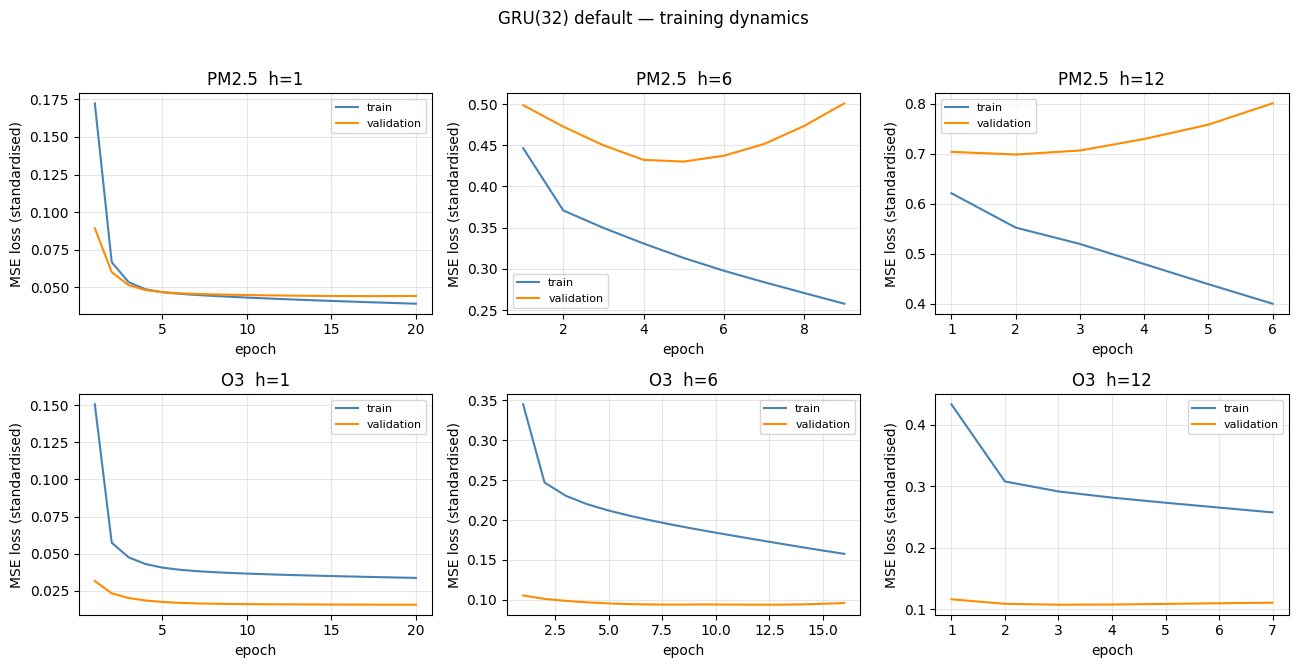

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharex=False)
for ax, (target, h) in zip(axes.flat, settings):
    hist = gru_results.loc[(gru_results["target"] == target) &
                           (gru_results["h"] == h), "history"].iloc[0]
    epochs = range(1, len(hist["loss"]) + 1)
    ax.plot(epochs, hist["loss"],     label="train",      color="steelblue")
    ax.plot(epochs, hist["val_loss"], label="validation", color="darkorange")
    ax.set_title(f"{target}  h={h}")
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss (standardised)")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle("GRU(32) default — training dynamics", y=1.02)
plt.tight_layout(); plt.show()

Two patterns are worth pausing on, because they recur throughout the rest of the notebook.

**PM2.5 *h* = 6 and *h* = 12 overfit early.** Train loss keeps falling, but validation loss bottoms out after just a few epochs and then climbs again. EarlyStopping (patience 4) rescues us — it restores the weights from the validation minimum — but it is a clear signal that the model has more capacity than the harder PM2.5 settings can use cleanly. PM2.5 has heavy-tailed smog spikes that appear in different patterns across train and validation periods; the model learns spike shapes in train that do not transfer. This directly motivates **dropout** in §5 — adding noise during training reduces this kind of memorisation.

**O&#8323; validation loss sits well below train loss.** Counter-intuitive at first glance — does the model fit validation *better* than training? No. This is a **chronological-split artifact**: the StandardScaler is fit on train, giving train data unit variance by construction; the validation slice (the 10% chunk between train and test) happens to land in a calmer O&#8323; period (lower spread) and so its standardised MSE is lower regardless of how good the model is. This is precisely why **hyperparameter tuning must use validation, but the final unbiased estimate has to come from the test set** — see §3 and §6. We will see in §6 that test MAE on O&#8323; is much closer to train than this validation curve suggests.

---
## 3. What can we tune?

A recurrent forecaster has many knobs. They fall into two broad groups.

### Algorithmic — choices about *how* the model learns

- **Loss function** — MSE punishes large errors quadratically. Alternatives like **Huber** linearly cap the contribution of outlier residuals, useful when the target distribution has heavy tails.
- **Optimizer + learning rate** — Adam at 10⁻³ is a robust default. The order of magnitude is what matters most; fine-tuning within the central decade has diminishing returns.
- **Regularization (dropout)** — randomly zero a fraction of activations during training, forcing the model to spread information across multiple paths. Helps with overfitting.
- **Learning-rate schedule** — keep LR constant, or decay it (cosine annealing, `ReduceLROnPlateau`) over training. Mostly a polishing step.
- **Batch size** — gradient noise vs throughput tradeoff. Default 64 works well here.

### Architectural — choices about model *structure*

- **Window size *T*** — how many past hours the model sees before each prediction. We use *T* = 24 (one full day of context).
- **Hidden units** — capacity of each recurrent layer. More units = more parameters = potentially better fit, also more risk of overfitting.
- **Number of layers** — depth. Stacked GRUs/LSTMs can model longer-range dependencies but are harder to train without more data.
- **Bidirectionality, attention, residual connections** — richer variants beyond vanilla recurrence; not covered here.

### How to compare configurations

**Hyperparameter selection should be done on the validation set, not the test set.** Tuning against test would leak information and give optimistically biased final numbers. The split policy in this notebook:

- Models are **trained** on `train` (with EarlyStopping watching `val_loss`).
- Hyperparameter comparisons in §4 and §5 use **validation MAE** (`val_MAE`).
- The final tuned configuration is evaluated **once** on the test set in §6 — a clean, unbiased estimate of generalisation.

---
## 4. Loss function — Huber instead of MSE

**MSE** punishes big errors quadratically. A 50 &micro;g/m&sup3; miss contributes 50² = 2500 to the loss; a 5 &micro;g/m&sup3; miss contributes 25. The single 50-&micro;g miss therefore dominates the average, and the gradient pulls the model very hard toward fitting that one outlier — at the expense of the typical hours.

**Huber** is a hybrid. Below a threshold δ it behaves like MSE (smooth gradient, exact fit). Above δ it switches to a linear (absolute-error) penalty:

$$
L_{\delta}(e) = \begin{cases}
\tfrac{1}{2} e^2                      & |e| \le \delta \\
\delta \cdot \bigl(|e| - \tfrac{1}{2} \delta\bigr) & |e| > \delta
\end{cases}
$$

Effect: outliers contribute *linearly* (not quadratically) to the gradient, so the model is less yanked around by them and fits typical hours better.

**Why this matters for PM2.5.** PM2.5 has occasional smog-episode spikes that are 5&ndash;10&times; the median. With MSE those spikes dominate the loss; with Huber their contribution is bounded.

Keras has it built-in: `keras.losses.Huber(delta=1.0)`. The default δ = 1.0 in standardised space is a sensible choice for our data (residuals beyond 1 std deviation are treated as outliers).

Quick side-by-side comparison on PM2.5 *h* = 12, GRU(32), default everything else — comparing on **validation** (hyperparameter-tuning convention):

In [6]:
rows = []
for loss_name, loss_fn in [("mse",   "mse"),
                           ("huber", keras.losses.Huber(delta=1.0))]:
    out = train_gru("PM2.5", 12, loss=loss_fn)
    rows.append({"loss": loss_name, **out})
    print(f"  loss={loss_name:<6s}  val_MAE={out['val_MAE']:6.2f}  "
          f"val_RMSE={out['val_RMSE']:6.2f}  val_R2={out['val_R2']:+.3f}  "
          f"epochs={out['epochs']:>2}  t={out['time_s']:.1f}s")

loss_results = pd.DataFrame(rows)
print(loss_results[["loss", "val_MAE", "val_RMSE", "val_R2", "epochs", "time_s"]].round(3).to_string(index=False))

  loss=mse     val_MAE= 47.57  val_RMSE= 67.87  val_R2=+0.332  epochs= 6  t=6.2s


  loss=huber   val_MAE= 45.54  val_RMSE= 66.36  val_R2=+0.362  epochs= 8  t=8.0s
 loss  val_MAE  val_RMSE  val_R2  epochs  time_s
  mse    47.57    67.875   0.332       6   6.210
huber    45.54    66.359   0.362       8   7.993


**Huber reduces validation MAE on PM2.5 *h* = 12** by about 2 &micro;g/m&sup3; vs MSE on this run. Nothing magical — Huber simply down-weights large residuals during training, so the model is less pulled around by spike examples and fits typical hours better.

Note that **MAE drops more than RMSE** — Huber doesn't directly reduce outlier predictions, only their grip on the gradient. MAE weights all residuals equally so it picks up the improvement on typical hours; RMSE is dominated by the largest residuals (squared), which Huber barely changes.

We carry **Huber forward** as the loss function.

---
## 5. Regularization — Dropout

**What dropout does.** During each training step, randomly set a fraction `p` of the activations in a layer to zero. A different random mask is used each step, so the model cannot rely on any single neuron — it has to spread information across multiple paths. At **inference**, all activations are kept (and scaled appropriately) — there is no randomness at predict time.

**Why this helps.** Models with enough capacity (like a GRU) can memorise training noise instead of generalisable patterns. Dropping random subsets during training acts like training many smaller models that share weights, then averaging — a form of implicit ensembling that reduces overfitting.

**Where to put it.** We add a `Dropout(0.3)` layer **after the GRU**, before the Dense head. Other variants exist (`recurrent_dropout` applies the mask inside the GRU at every time-step), but post-layer dropout is simpler and works well here.

Side-by-side comparison on PM2.5 *h* = 12, GRU(32) + Huber, comparing on validation:

In [7]:
rows = []
for d in [0.0, 0.3]:
    out = train_gru("PM2.5", 12, dropout=d,
                    loss=keras.losses.Huber(delta=1.0))
    rows.append({"dropout": d, **out})
    print(f"  dropout={d:.1f}  val_MAE={out['val_MAE']:6.2f}  "
          f"val_RMSE={out['val_RMSE']:6.2f}  val_R2={out['val_R2']:+.3f}  "
          f"epochs={out['epochs']:>2}  t={out['time_s']:.1f}s")

drop_results = pd.DataFrame(rows)
print(drop_results[["dropout", "val_MAE", "val_RMSE", "val_R2", "epochs", "time_s"]].round(3).to_string(index=False))

  dropout=0.0  val_MAE= 45.54  val_RMSE= 66.36  val_R2=+0.362  epochs= 8  t=8.1s


  dropout=0.3  val_MAE= 44.86  val_RMSE= 66.23  val_R2=+0.364  epochs= 8  t=8.2s
 dropout  val_MAE  val_RMSE  val_R2  epochs  time_s
     0.0    45.54    66.359   0.362       8   8.071
     0.3    44.86    66.231   0.364       8   8.151


Adding **Dropout(0.3)** on top of Huber reduces validation MAE by another ≈0.7 &micro;g/m&sup3; (45.5 &rarr; 44.9). Combined with the Huber gain from §4, the tuned config now sits about 2.7 &micro;g/m&sup3; below the default GRU baseline (val_MAE 47.6 &rarr; 44.9) on this hard setting.

*A note on scale.* On a small model like GRU(32), the gain from dropout is **modest** — overfitting is already mild and EarlyStopping handles much of it. Dropout becomes more important on larger models (more capacity → more overfit risk). We include it here both for the small consistent gain and as standard practice that scales naturally to bigger architectures.

We carry **Huber + Dropout(0.3)** forward to §6 where we apply the combined configuration to all six (target, *h*) settings — and switch to **test-set** evaluation for the final unbiased numbers.

---
## 6. Final benchmark — tuned GRU on all six settings

We now apply the tuned configuration **(Huber + Dropout(0.3))** to all six (target, *h*) combinations and report **test-set** metrics — the only unbiased estimate of generalisation, since the test set has not been touched during hyperparameter selection.

We compare three columns:

- **naive** — best of {persistence, seasonal-naive} from NB2
- **GRU default** — §2 of this notebook (Adam 10⁻³, MSE, no dropout)
- **GRU tuned** — Huber + Dropout(0.3)

In [9]:
settings = [("PM2.5", 1), ("PM2.5", 6), ("PM2.5", 12),
            ("O3",    1), ("O3",    6), ("O3",    12)]

rows = []
for target, h in settings:
    out = train_gru(target, h, dropout=0.3,
                    loss=keras.losses.Huber(delta=1.0))
    rows.append({"target": target, "h": h, **out})
    print(f"  GRU(tuned)  {target:<5s} h={h:>2}  MAE={out['MAE']:6.2f}  "
          f"RMSE={out['RMSE']:6.2f}  R2={out['R2']:+.3f}  "
          f"epochs={out['epochs']:>2}  t={out['time_s']:.1f}s")

tuned_results = pd.DataFrame(rows)

  GRU(tuned)  PM2.5 h= 1  MAE=  9.49  RMSE= 15.99  R2=+0.965  epochs=20  t=21.4s


  GRU(tuned)  PM2.5 h= 6  MAE= 29.97  RMSE= 47.06  R2=+0.689  epochs=15  t=15.5s


  GRU(tuned)  PM2.5 h=12  MAE= 37.52  RMSE= 55.66  R2=+0.529  epochs= 8  t=8.1s


  GRU(tuned)  O3    h= 1  MAE=  8.11  RMSE= 12.64  R2=+0.962  epochs=20  t=21.5s


  GRU(tuned)  O3    h= 6  MAE= 20.83  RMSE= 28.96  R2=+0.797  epochs=15  t=15.4s


  GRU(tuned)  O3    h=12  MAE= 24.91  RMSE= 33.47  R2=+0.730  epochs= 7  t=7.2s


In [10]:
# Naive numbers from NB2 (best of persistence / seasonal-naive)
naive_ref = pd.DataFrame([
    {"target": "PM2.5", "h":  1, "naive_MAE": 10.11, "naive_RMSE": 17.99, "naive_R2": 0.96},
    {"target": "PM2.5", "h":  6, "naive_MAE": 32.29, "naive_RMSE": 52.65, "naive_R2": 0.61},
    {"target": "PM2.5", "h": 12, "naive_MAE": 42.80, "naive_RMSE": 67.93, "naive_R2": 0.30},
    {"target": "O3",    "h":  1, "naive_MAE": 11.20, "naive_RMSE": 17.58, "naive_R2": 0.93},
    {"target": "O3",    "h":  6, "naive_MAE": 31.59, "naive_RMSE": 44.99, "naive_R2": 0.51},
    {"target": "O3",    "h": 12, "naive_MAE": 31.69, "naive_RMSE": 45.00, "naive_R2": 0.51},
])

final = (naive_ref
    .merge(gru_results[["target", "h", "MAE", "RMSE", "R2"]].rename(
        columns={"MAE": "GRU_def_MAE", "RMSE": "GRU_def_RMSE", "R2": "GRU_def_R2"}),
        on=["target", "h"])
    .merge(tuned_results[["target", "h", "MAE", "RMSE", "R2"]].rename(
        columns={"MAE": "GRU_tuned_MAE", "RMSE": "GRU_tuned_RMSE", "R2": "GRU_tuned_R2"}),
        on=["target", "h"])
)

print("=== Test MAE [\u00b5g/m\u00b3] ===")
print(final[["target", "h", "naive_MAE", "GRU_def_MAE", "GRU_tuned_MAE"]].round(2).to_string(index=False))
print("\n=== Test RMSE [\u00b5g/m\u00b3] ===")
print(final[["target", "h", "naive_RMSE", "GRU_def_RMSE", "GRU_tuned_RMSE"]].round(2).to_string(index=False))
print("\n=== Test R\u00b2 ===")
print(final[["target", "h", "naive_R2", "GRU_def_R2", "GRU_tuned_R2"]].round(3).to_string(index=False))

=== Test MAE [µg/m³] ===
target  h  naive_MAE  GRU_def_MAE  GRU_tuned_MAE
 PM2.5  1      10.11         9.71           9.49
 PM2.5  6      32.29        30.01          29.97
 PM2.5 12      42.80        39.64          37.52
    O3  1      11.20         8.20           8.11
    O3  6      31.59        20.86          20.83
    O3 12      31.69        24.62          24.91

=== Test RMSE [µg/m³] ===
target  h  naive_RMSE  GRU_def_RMSE  GRU_tuned_RMSE
 PM2.5  1       17.99         15.84           15.99
 PM2.5  6       52.65         46.31           47.06
 PM2.5 12       67.93         57.71           55.66
    O3  1       17.58         12.66           12.64
    O3  6       44.99         28.86           28.96
    O3 12       45.00         33.59           33.47

=== Test R² ===
target  h  naive_R2  GRU_def_R2  GRU_tuned_R2
 PM2.5  1      0.96       0.966         0.965
 PM2.5  6      0.61       0.699         0.689
 PM2.5 12      0.30       0.494         0.529
    O3  1      0.93       0.962         

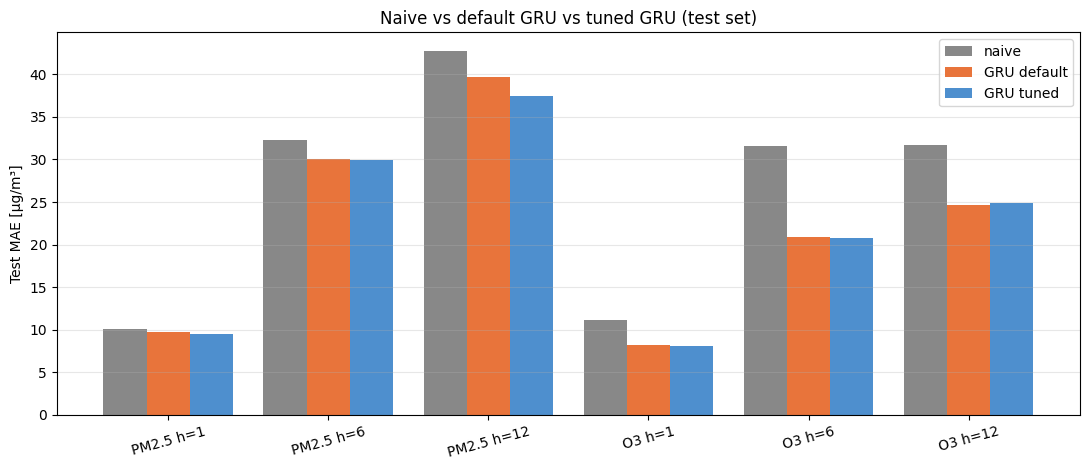

In [11]:
# Bar chart: naive vs default GRU vs tuned GRU per setting
labels = [f"{t} h={h}" for t, h in settings]
x = np.arange(len(labels))
w = 0.27

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.bar(x - w, final["naive_MAE"],     w, label="naive",       color="#888")
ax.bar(x,     final["GRU_def_MAE"],   w, label="GRU default", color="#E8743B")
ax.bar(x + w, final["GRU_tuned_MAE"], w, label="GRU tuned",   color="#4E8FCE")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel("Test MAE [\u00b5g/m\u00b3]")
ax.set_title("Naive vs default GRU vs tuned GRU (test set)")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

Reading the comparison:

- **The biggest gap is from naive to either GRU variant**, especially at *h* ≥ 6. Adopting *any* learned recurrent model is the step that brings the largest absolute change.
- **Tuning helps modestly and unevenly.** On harder settings (PM2.5 *h* = 12 in particular) the Huber + Dropout combo shaves a few &micro;g/m&sup3; off the default; on easier ones (PM2.5 *h* = 1, O&#8323; *h* = 1) the difference is within seed-noise range.
- **Each technique has a specific role.** Huber down-weights outlier residuals; Dropout regularises against memorisation. The gains here are modest because the model is small and the dataset is moderate-sized — but both are standard tools and become essential building blocks on bigger problems.

---
## Recap

- **GRU is a streamlined LSTM.** Two gates instead of three, single hidden state, ≈75 % the parameters of a same-size LSTM. On this dataset GRU(32) matches LSTM(32) on most settings, with margins below the seed-noise level.
- **Huber loss tames outlier residuals.** On PM2.5 *h* = 12 (heavy-tailed target with smog spikes), Huber drops val MAE by ≈2 µg/m³ vs MSE. The gain comes from down-weighting large residuals during training, not from changing what the model predicts at inference.
- **Dropout(0.3) regularises, modestly.** On a small model the extra gain is ≈0.7 µg/m³ — overfitting is already mild and EarlyStopping handles much of it. Dropout becomes more important on larger models.
- **Tune on validation, evaluate on test.** Hyperparameter A/B comparisons in §4 and §5 use val_MAE; the test set is touched once in §6 for the final unbiased number.
- **The biggest gap is naive → learned.** Tuning shaves a few µg/m³ off the default GRU on hard settings; the architecture/loss/regularisation choices we tried cluster within noise of each other.

**What's next.** NB5 asks a different question: instead of more model tuning, what if we gave the model *more information*? It uses **future-informed inputs** (look-ahead features drawn from the dataset) to measure an empirical ceiling on what better forecast features could buy us.

### Check your understanding

1. GRU(32) has ≈4,700 trainable parameters; LSTM(32) has ≈6,200 — about 76 %. Why does GRU often match LSTM in accuracy despite the smaller parameter count? What's the architectural reason?
2. Huber gives a clear 2 µg/m³ gain on PM2.5 *h* = 12 but a smaller gain on O&#8323; *h* = 12. What's different about the **target distribution** that explains why Huber helps PM2.5 more than O&#8323;?
3. We compare configurations in §4 and §5 using **val_MAE**, not test_MAE. What concrete kind of bias would creep in if we used test_MAE for this hyperparameter selection?
4. On a small GRU(32), Dropout(0.3) gives ≈0.7 µg/m³ improvement. On a hypothetical GRU(256), would you expect the dropout gain to be (a) about the same, (b) smaller, or (c) larger? Why?

*(Answers: 1 — GRU has three weight matrices instead of LSTM's four (the output gate is gone, and there is no separate cell state). On shorter sequences the extra LSTM machinery rarely earns its keep; GRU's update + reset gates already capture the "keep / overwrite" decision the model needs. 2 — PM2.5 has a heavy-tailed distribution with smog-episode spikes 5–10× the median; MSE is dominated by those few large residuals, and Huber's linear cap above δ stops them from steering the gradient. O&#8323; is more peak-bounded by the daily cycle, so it has fewer extreme outliers and Huber has less to "fix". 3 — using test_MAE for HP selection is a form of data leakage: the test set is no longer "unseen", and the reported test number is optimistically biased toward whatever HP happened to win on this particular fold. With multiple comparisons, you end up cherry-picking. 4 — (c) larger. Dropout's job is to suppress overfitting, and overfitting risk grows with capacity. A GRU(256) has roughly 8× the parameters of GRU(32) and would memorise training noise much more aggressively without dropout — so the regularisation gain should be bigger. EarlyStopping alone is not enough at that scale.)*